In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración estética general para los gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Carga del dataset desde UCI / URL pública
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Limpieza de nombres de columnas
df.columns = df.columns.str.strip()

# Renombrar columnas para mayor comodidad
df.rename(columns={
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rot_speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear',
    'Machine failure': 'machine_failure',
    'TWF': 'twf',
    'HDF': 'hdf',
    'PWF': 'pwf',
    'OSF': 'osf',
    'RNF': 'rnf'
}, inplace=True)

print('Dataset cargado correctamente.')
print(f'Dimensiones: {df.shape}')

Dataset cargado correctamente.
Dimensiones: (10000, 14)


## 1. Problema y Datos & 2. Justificación de la IA

- **Problema y Datos:** El dataset *AI4I 2020 Predictive Maintenance* es un conjunto de datos sintético que replica escenarios reales de mantenimiento industrial. Contiene **10,000 instancias** con 14 características que describen condiciones operativas de una máquina (temperatura del aire, temperatura del proceso, velocidad de rotación, torque y desgaste de herramienta) junto con su resultado: si la máquina falló o no (`machine_failure`). La variable objetivo es binaria (0 = sin falla, 1 = falla), lo que enmarca el problema como una **clasificación binaria**.

- **Justificación de la IA:** En entornos industriales, detectar fallas antes de que ocurran puede ahorrar millones en paradas no programadas. Las relaciones entre variables como torque, desgaste de herramienta y temperatura no siguen patrones lineales simples; además, el dataset presenta **desbalance de clases** significativo (la mayoría de instancias no presentan falla). Un modelo de Inteligencia Artificial supervisado puede aprender estos patrones complejos, generalizar sobre datos nuevos y superar ampliamente cualquier sistema basado en umbrales fijos manuales.

In [ ]:
df.head(10)

,UDI,Product ID,Type,air_temp,process_temp,rot_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [ ]:
# 3.1 Información general del dataset
print('=== Información General ===')
df.info()
print()

# 3.2 Estadísticas descriptivas
print('=== Estadísticas Descriptivas ===')
display(df.describe())

# 3.3 Valores nulos
print('=== Valores Nulos por Columna ===')
nulls = df.isnull().sum()
print(nulls)
print(f'\nTotal de valores nulos: {nulls.sum()}')

# 3.4 Duplicados
print(f'\nFilas duplicadas: {df.duplicated().sum()}')

# 3.5 Distribución de la variable objetivo
print('\n=== Distribución de la Variable Objetivo (machine_failure) ===')
vc = df['machine_failure'].value_counts()
pct = df['machine_failure'].value_counts(normalize=True) * 100
resumen = pd.DataFrame({'Conteo': vc, 'Porcentaje (%)': pct.round(2)})
resumen.index = ['Sin falla (0)', 'Con falla (1)']
print(resumen)

=== Información General ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   UDI              10000 non-null  int64  
 1   Product ID       10000 non-null  object 
 2   Type             10000 non-null  object 
 3   air_temp         10000 non-null  float64
 4   process_temp     10000 non-null  float64
 5   rot_speed        10000 non-null  int64  
 6   torque           10000 non-null  float64
 7   tool_wear        10000 non-null  int64  
 8   machine_failure  10000 non-null  int64  
 9   twf              10000 non-null  int64  
 10  hdf              10000 non-null  int64  
 11  pwf              10000 non-null  int64  
 12  osf              10000 non-null  int64  
 13  rnf              10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB

=== Estadísticas Descriptivas ===


,UDI,air_temp,process_temp,rot_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


=== Valores Nulos por Columna ===
UDI                0
Product ID         0
Type               0
air_temp           0
process_temp       0
rot_speed          0
torque             0
tool_wear          0
machine_failure    0
twf                0
hdf                0
pwf                0
osf                0
rnf                0
dtype: int64

Total de valores nulos: 0

Filas duplicadas: 0

=== Distribución de la Variable Objetivo (machine_failure) ===
               Conteo  Porcentaje (%)
Sin falla (0)    9661           96.61
Con falla (1)     339            3.39


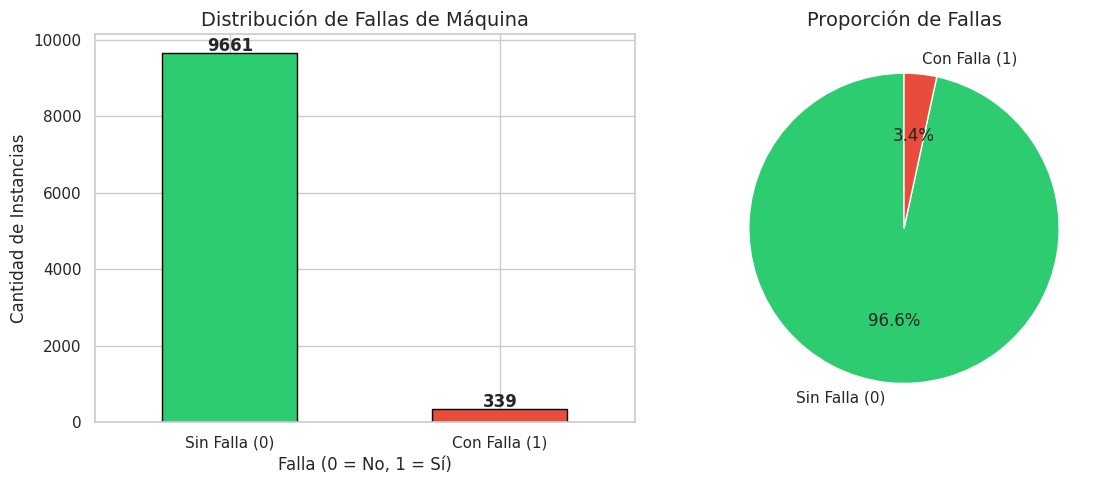

Insight: El dataset presenta un fuerte desbalance de clases. Aproximadamente el 97% de los datos corresponde a operación normal y solo el 3% a fallas reales. Esto debe tenerse en cuenta al entrenar el modelo.


In [ ]:
# 4.1 Distribución de la variable objetivo (gráfico)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo
colores = ['#2ecc71', '#e74c3c']
df['machine_failure'].value_counts().plot(
    kind='bar', ax=axes[0], color=colores, edgecolor='black'
)
axes[0].set_title('Distribución de Fallas de Máquina')
axes[0].set_xlabel('Falla (0 = No, 1 = Sí)')
axes[0].set_ylabel('Cantidad de Instancias')
axes[0].set_xticklabels(['Sin Falla (0)', 'Con Falla (1)'], rotation=0)
for i, v in enumerate(df['machine_failure'].value_counts()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Torta
df['machine_failure'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colores,
    labels=['Sin Falla (0)', 'Con Falla (1)'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Proporción de Fallas')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('Insight: El dataset presenta un fuerte desbalance de clases. Aproximadamente el 97% de los datos corresponde a operación normal y solo el 3% a fallas reales. Esto debe tenerse en cuenta al entrenar el modelo.')

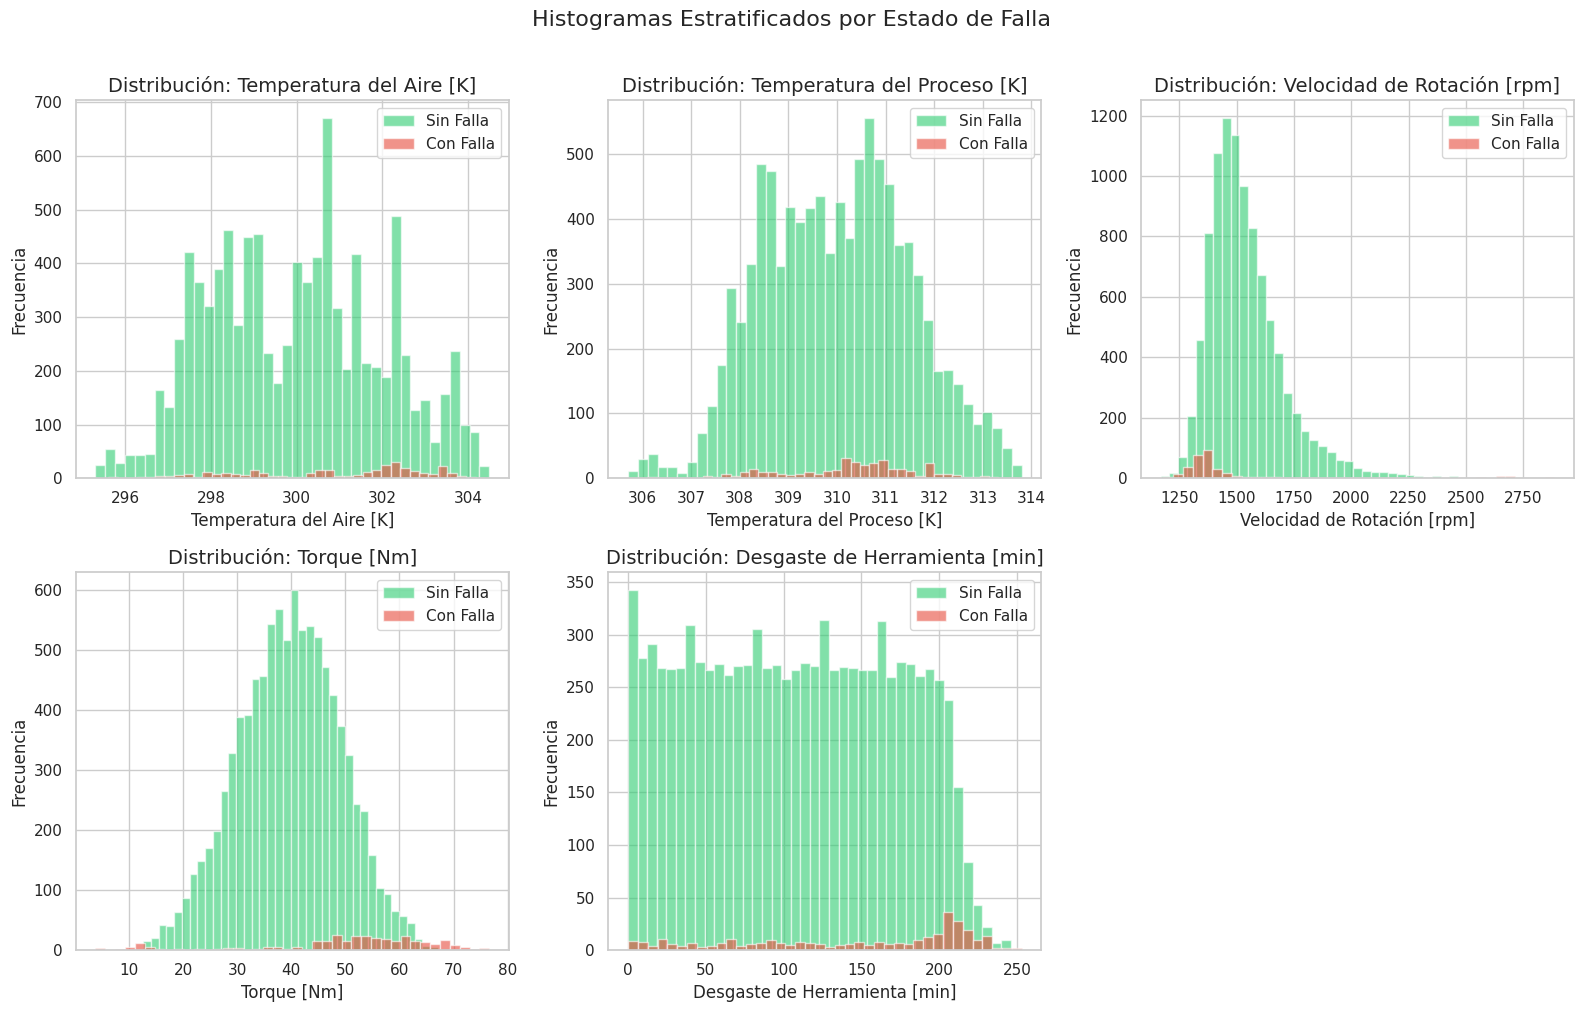

Insight: Las distribuciones de torque y velocidad de rotación muestran diferencias notables entre clases. Las máquinas con falla tienden a operar a torques más altos o velocidades más bajas. El desgaste de herramienta también es mayor en instancias de falla.


In [ ]:
# 4.2 Histogramas estratificados de variables numéricas continuas
features_continuas = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear']
labels_features = {
    'air_temp': 'Temperatura del Aire [K]',
    'process_temp': 'Temperatura del Proceso [K]',
    'rot_speed': 'Velocidad de Rotación [rpm]',
    'torque': 'Torque [Nm]',
    'tool_wear': 'Desgaste de Herramienta [min]'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_continuas):
    for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
        subset = df[df['machine_failure'] == label][feat]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label='Sin Falla' if label == 0 else 'Con Falla',
                     edgecolor='white')
    axes[i].set_title(f'Distribución: {labels_features[feat]}')
    axes[i].set_xlabel(labels_features[feat])
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

axes[-1].axis('off')  # Ocultar el subplot sobrante
plt.suptitle('Histogramas Estratificados por Estado de Falla', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print('Insight: Las distribuciones de torque y velocidad de rotación muestran diferencias notables entre clases. Las máquinas con falla tienden a operar a torques más altos o velocidades más bajas. El desgaste de herramienta también es mayor en instancias de falla.')

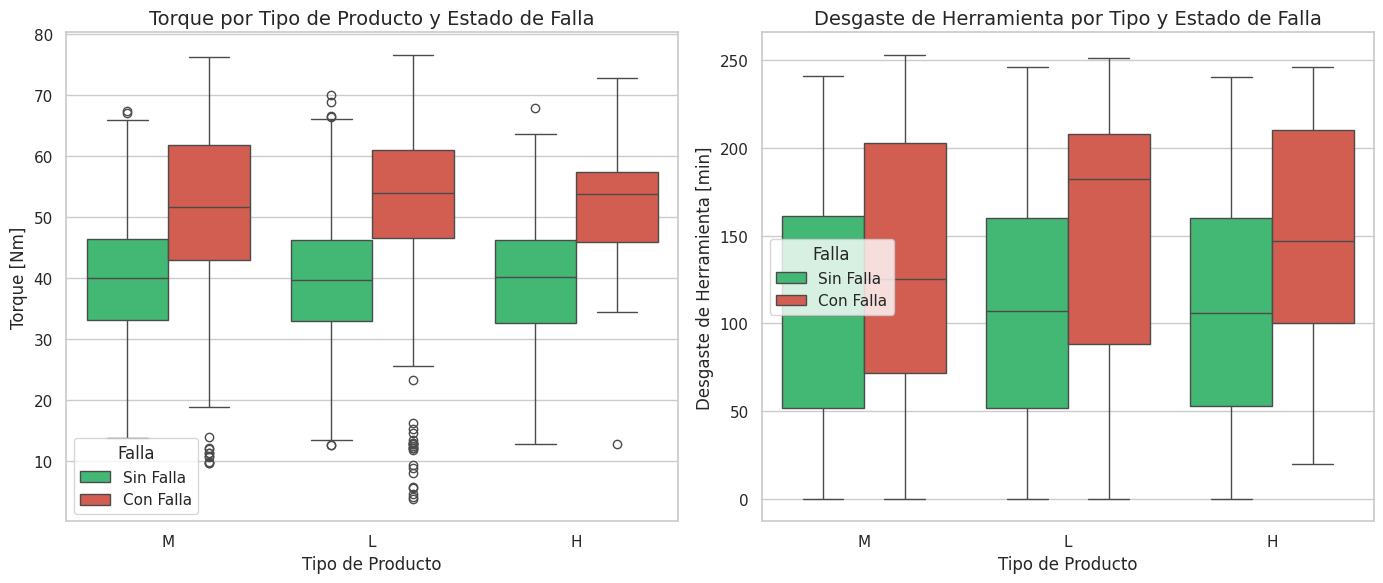

Insight: Los productos de tipo L (baja calidad) presentan mayor mediana de desgaste de herramienta en instancias con falla, consistente con el proceso de adición de desgaste (2 min adicionales para L). El torque en fallas es consistentemente más alto en todos los tipos de producto.


In [ ]:
# 4.3 Boxplots por tipo de producto
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Type', y='torque', hue='machine_failure',
            palette={0: '#2ecc71', 1: '#e74c3c'}, ax=axes[0])
axes[0].set_title('Torque por Tipo de Producto y Estado de Falla')
axes[0].set_xlabel('Tipo de Producto')
axes[0].set_ylabel('Torque [Nm]')
legend = axes[0].get_legend()
legend.set_title('Falla')
for t, l in zip(legend.texts, ['Sin Falla', 'Con Falla']):
    t.set_text(l)

sns.boxplot(data=df, x='Type', y='tool_wear', hue='machine_failure',
            palette={0: '#2ecc71', 1: '#e74c3c'}, ax=axes[1])
axes[1].set_title('Desgaste de Herramienta por Tipo y Estado de Falla')
axes[1].set_xlabel('Tipo de Producto')
axes[1].set_ylabel('Desgaste de Herramienta [min]')
legend2 = axes[1].get_legend()
legend2.set_title('Falla')
for t, l in zip(legend2.texts, ['Sin Falla', 'Con Falla']):
    t.set_text(l)

plt.tight_layout()
plt.show()

print('Insight: Los productos de tipo L (baja calidad) presentan mayor mediana de desgaste de herramienta en instancias con falla, consistente con el proceso de adición de desgaste (2 min adicionales para L). El torque en fallas es consistentemente más alto en todos los tipos de producto.')

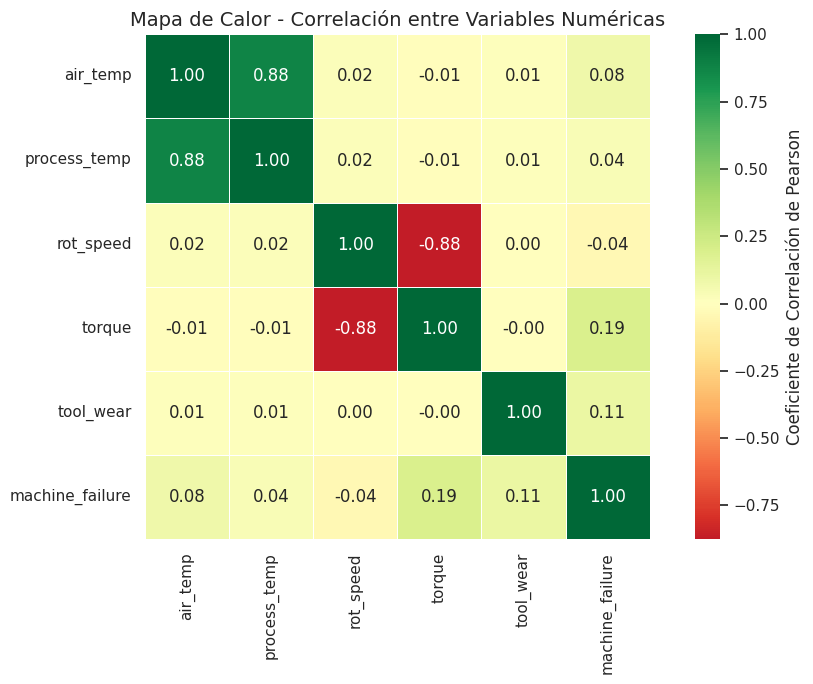

In [ ]:
# 4.4 Mapa de calor de correlaciones
cols_numericas = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'machine_failure']
corr_matrix = df[cols_numericas].corr()

plt.figure(figsize=(10, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)
plt.title('Mapa de Calor - Correlación entre Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

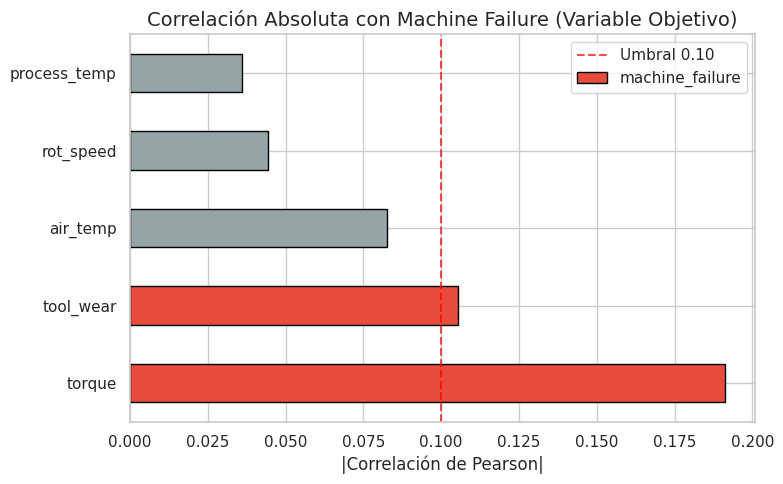


Insights (Patrones y Correlación con Variable Objetivo):
  - Torque [Nm]: 0.19
  - Desgaste de Herramienta [min]: 0.11
  - Temperatura del Aire [K]: 0.08
  - Velocidad de Rotación [rpm]: 0.04
  - Temperatura del Proceso [K]: 0.04

Conclusión del análisis de correlación:
La variable con mayor correlación con la falla es "Torque [Nm]".
Las correlaciones lineales son moderadas, lo que sugiere relaciones no lineales entre variables y la ocurrencia de fallas — justificando el uso de modelos de ML más complejos (Random Forest, XGBoost) en lugar de regresión logística simple.


In [ ]:
# 4.5 Análisis de correlación con la variable objetivo
corr_target = df[cols_numericas].corr()['machine_failure'].drop('machine_failure').abs().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colores_barras = ['#e74c3c' if v > 0.1 else '#95a5a6' for v in corr_target]
corr_target.plot(kind='barh', color=colores_barras, edgecolor='black')
plt.title('Correlación Absoluta con Machine Failure (Variable Objetivo)')
plt.xlabel('|Correlación de Pearson|')
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='Umbral 0.10')
plt.legend()
plt.tight_layout()
plt.show()

print('\nInsights (Patrones y Correlación con Variable Objetivo):')
for feat, val in corr_target.items():
    label = labels_features.get(feat, feat)
    print(f'  - {label}: {val:.2f}')

print('\nConclusión del análisis de correlación:')
top_feat = corr_target.index[0]
print(f'La variable con mayor correlación con la falla es "{labels_features.get(top_feat, top_feat)}".')
print('Las correlaciones lineales son moderadas, lo que sugiere relaciones no lineales entre variables y la ocurrencia de fallas — justificando el uso de modelos de ML más complejos (Random Forest, XGBoost) en lugar de regresión logística simple.')

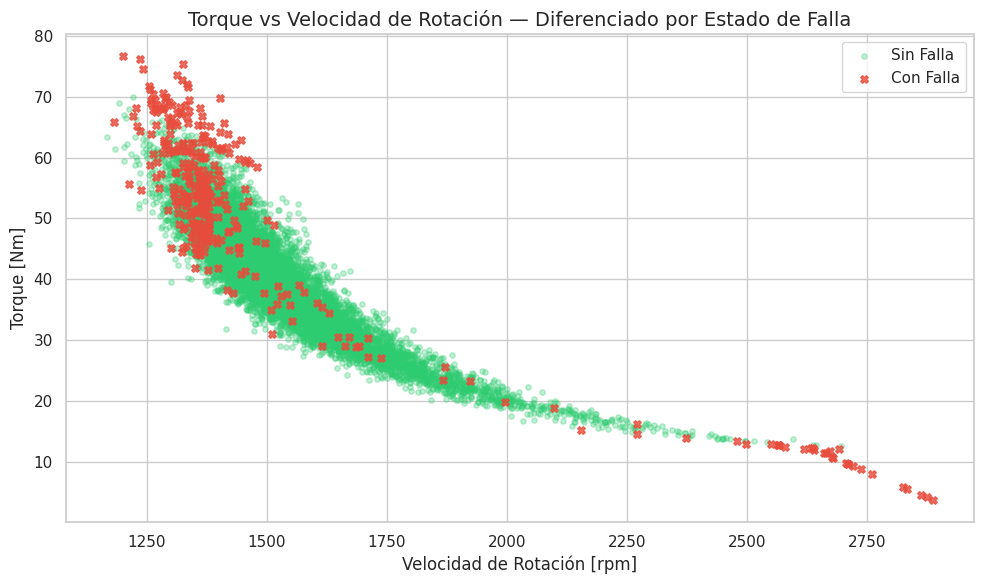

Insight: Se observan dos zonas de riesgo: torque muy alto con baja velocidad (posible sobretensión) y torque bajo con alta velocidad (posible disipación de calor insuficiente). El modelo de IA deberá capturar estas regiones de decisión no lineales.


In [ ]:
# 4.7 Scatter plot: Torque vs Velocidad de Rotación (diferenciado por falla)
plt.figure(figsize=(10, 6))

sin_falla = df[df['machine_failure'] == 0]
con_falla = df[df['machine_failure'] == 1]

plt.scatter(sin_falla['rot_speed'], sin_falla['torque'],
            alpha=0.3, c='#2ecc71', label='Sin Falla', s=15)
plt.scatter(con_falla['rot_speed'], con_falla['torque'],
            alpha=0.8, c='#e74c3c', label='Con Falla', s=30, marker='X')

plt.title('Torque vs Velocidad de Rotación — Diferenciado por Estado de Falla')
plt.xlabel('Velocidad de Rotación [rpm]')
plt.ylabel('Torque [Nm]')
plt.legend()
plt.tight_layout()
plt.show()

print('Insight: Se observan dos zonas de riesgo: torque muy alto con baja velocidad (posible sobretensión) y torque bajo con alta velocidad (posible disipación de calor insuficiente). El modelo de IA deberá capturar estas regiones de decisión no lineales.')

In [ ]:
# Codificación de la variable 'Type' (L, M, H) usando Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

print('Mapeo de codificación para Type:')
for clase, codigo in zip(le.classes_, range(len(le.classes_))):
    print(f'  {clase} → {codigo}')

# Verificación
print(f'\nColumnas disponibles tras codificación: {list(df.columns)}')

# Preparar features y target para futura etapa de modelado
feature_cols = ['Type_encoded', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear']
X = df[feature_cols]
y = df['machine_failure']

print(f'\nShape de X (features): {X.shape}')
print(f'Shape de y (target):   {y.shape}')
print(f'Distribución del target: {y.value_counts().to_dict()}')

Mapeo de codificación para Type:
  H → 0
  L → 1
  M → 2

Columnas disponibles tras codificación: ['UDI', 'Product ID', 'Type', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'Type_encoded']

Shape de X (features): (10000, 6)
Shape de y (target):   (10000,)
Distribución del target: {0: 9661, 1: 339}


In [ ]:
import pandas as pd

# Carga del dataset desde UCI / URL pública
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Limpieza de nombres de columnas
df.columns = df.columns.str.strip()

# Renombrar columnas para mayor comodidad
df.rename(columns={
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rot_speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear',
    'Machine failure': 'machine_failure',
    'TWF': 'twf',
    'HDF': 'hdf',
    'PWF': 'pwf',
    'OSF': 'osf',
    'RNF': 'rnf'
}, inplace=True)

# Re-ejecutar la consulta original
display(df[df['torque'] < 15][['torque', 'tool_wear', 'twf', 'hdf', 'pwf', 'osf', 'rnf']])

,torque,tool_wear,twf,hdf,pwf,osf,rnf
50,4.6,143,0,0,1,0,0
194,10.7,86,0,0,1,0,0
344,13.8,29,0,0,0,0,0
380,12.8,127,0,0,1,0,0
463,4.2,118,0,0,1,0,0
847,5.6,213,0,0,1,0,0
903,14.6,149,0,0,1,0,0
1095,9.3,18,0,0,1,0,0
1209,13.3,98,0,0,0,0,0
1234,14.0,166,0,0,0,0,0
